Data path: /Users/sreeragm/fraud-decision-engine/data/creditcard.csv
Reports path: /Users/sreeragm/fraud-decision-engine/reports

Dataset shape: (284807, 31)
Total fraud transactions: 492

TEMPORAL SPLIT
Train      : 199,364 rows
Validation : 42,721 rows
Test       : 42,722 rows

Fraud counts:
Train      : 384
Validation : 56
Test       : 52

MODEL A — CLASS WEIGHTED XGBOOST
scale_pos_weight: 518.1770833333334

Training...
Complete.

MODEL B — SMOTE XGBOOST

Original training rows: 199364
SMOTE training rows: 397960

SMOTE class distribution:
Class
0    198980
1    198980
Name: count, dtype: int64

Training...
Complete.

VALIDATION RANKING PERFORMANCE

Class Weighted XGBoost
PR-AUC  : 0.861824
ROC-AUC : 0.988541

SMOTE XGBoost
PR-AUC  : 0.847495
ROC-AUC : 0.989125

VALIDATION BEST-F1 THRESHOLDS

Class Weighted XGBoost
Threshold : 0.56
Precision : 0.9773
Recall    : 0.7679
F1        : 0.8600
Alerts    : 44

SMOTE XGBoost
Threshold : 0.90
Precision : 0.9574
Recall    : 0.8036
F1        :

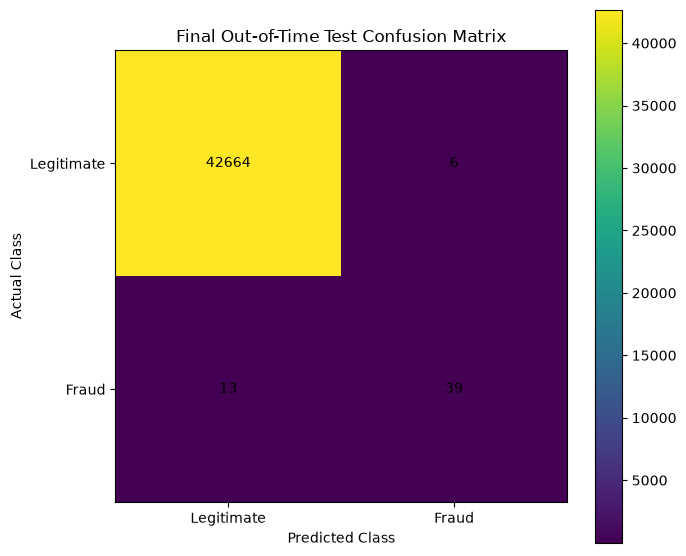


PHASE 9 COMPLETE

Generated files:
✓ phase9_validation_thresholds.csv
✓ frozen_decision_policy.json
✓ phase9_final_confusion_matrix.png
✓ phase9_final_test_results.csv
✓ phase9_test_scored_transactions.csv
✓ phase9_final_summary.json

FINAL MODEL
Class Weighted XGBoost

Frozen threshold: 0.56

Final test PR-AUC: 0.768413
Final test precision: 0.8667
Final test recall: 0.7500
Final test F1: 0.8041
Final test alerts: 45


The test set was NOT used to select the model or threshold.
The decision policy is now frozen.

Next: Phase 10 — Investigator Case Engine


In [1]:
# ============================================================
# PHASE 9 — FINAL MODEL SELECTION + FROZEN DECISION POLICY
# Credit Card Fraud Decision Engine
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier


# ============================================================
# 1. PATHS
# ============================================================

DATA_PATH = Path("../data/creditcard.csv")
REPORTS_PATH = Path("../reports")

REPORTS_PATH.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH.resolve())
print("Reports path:", REPORTS_PATH.resolve())


# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)

print("\nDataset shape:", df.shape)

print(
    "Total fraud transactions:",
    int(df["Class"].sum())
)


# ============================================================
# 3. SORT CHRONOLOGICALLY
# ============================================================

df = df.sort_values(
    "Time"
).reset_index(drop=True)


# ============================================================
# 4. TEMPORAL 70 / 15 / 15 SPLIT
# ============================================================

n = len(df)

train_end = int(n * 0.70)

validation_end = int(n * 0.85)

train = df.iloc[
    :train_end
].copy()

validation = df.iloc[
    train_end:validation_end
].copy()

test = df.iloc[
    validation_end:
].copy()


print("\n" + "=" * 70)
print("TEMPORAL SPLIT")
print("=" * 70)

print(
    f"Train      : {len(train):,} rows"
)

print(
    f"Validation : {len(validation):,} rows"
)

print(
    f"Test       : {len(test):,} rows"
)


print("\nFraud counts:")

print(
    "Train      :",
    int(train["Class"].sum())
)

print(
    "Validation :",
    int(validation["Class"].sum())
)

print(
    "Test       :",
    int(test["Class"].sum())
)


# ============================================================
# 5. FEATURES / TARGET
# ============================================================

X_train = train.drop(
    columns=["Class"]
)

y_train = train["Class"]


X_validation = validation.drop(
    columns=["Class"]
)

y_validation = validation["Class"]


X_test = test.drop(
    columns=["Class"]
)

y_test = test["Class"]


# ============================================================
# 6. EVALUATION FUNCTION
# ============================================================

def evaluate_predictions(
    y_true,
    probabilities,
    threshold
):

    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    return {

        "PR_AUC":
            average_precision_score(
                y_true,
                probabilities
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "Precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "TN": int(tn),

        "FP": int(fp),

        "FN": int(fn),

        "TP": int(tp),

        "Alerts": int(predictions.sum())
    }


# ============================================================
# 7. TRAIN MODEL A — CLASS WEIGHTED XGBOOST
# ============================================================

negative_count = (
    y_train == 0
).sum()

positive_count = (
    y_train == 1
).sum()

scale_pos_weight = (
    negative_count /
    positive_count
)


print("\n" + "=" * 70)
print("MODEL A — CLASS WEIGHTED XGBOOST")
print("=" * 70)

print(
    "scale_pos_weight:",
    scale_pos_weight
)


weighted_model = XGBClassifier(

    n_estimators=500,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="binary:logistic",

    eval_metric="aucpr",

    scale_pos_weight=
        scale_pos_weight,

    tree_method="hist",

    random_state=42,

    n_jobs=-1
)


print("\nTraining...")

weighted_model.fit(
    X_train,
    y_train
)

print("Complete.")


# ============================================================
# 8. TRAIN MODEL B — SMOTE XGBOOST
# ============================================================

print("\n" + "=" * 70)
print("MODEL B — SMOTE XGBOOST")
print("=" * 70)


smote = SMOTE(
    sampling_strategy=1.0,
    random_state=42
)


X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train,
        y_train
    )
)


print(
    "\nOriginal training rows:",
    len(X_train)
)

print(
    "SMOTE training rows:",
    len(X_train_smote)
)

print(
    "\nSMOTE class distribution:"
)

print(
    pd.Series(
        y_train_smote
    ).value_counts()
)


smote_model = XGBClassifier(

    n_estimators=500,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="binary:logistic",

    eval_metric="aucpr",

    scale_pos_weight=1,

    tree_method="hist",

    random_state=42,

    n_jobs=-1
)


print("\nTraining...")

smote_model.fit(
    X_train_smote,
    y_train_smote
)

print("Complete.")


# ============================================================
# 9. VALIDATION PREDICTIONS
# ============================================================

weighted_validation_prob = (
    weighted_model.predict_proba(
        X_validation
    )[:, 1]
)


smote_validation_prob = (
    smote_model.predict_proba(
        X_validation
    )[:, 1]
)


# ============================================================
# 10. VALIDATION RANKING PERFORMANCE
#
# IMPORTANT:
# Model selection happens HERE.
# TEST IS NOT TOUCHED.
# ============================================================

weighted_validation_pr_auc = (
    average_precision_score(
        y_validation,
        weighted_validation_prob
    )
)


smote_validation_pr_auc = (
    average_precision_score(
        y_validation,
        smote_validation_prob
    )
)


weighted_validation_roc_auc = (
    roc_auc_score(
        y_validation,
        weighted_validation_prob
    )
)


smote_validation_roc_auc = (
    roc_auc_score(
        y_validation,
        smote_validation_prob
    )
)


print("\n" + "=" * 70)
print("VALIDATION RANKING PERFORMANCE")
print("=" * 70)


print("\nClass Weighted XGBoost")

print(
    f"PR-AUC  : "
    f"{weighted_validation_pr_auc:.6f}"
)

print(
    f"ROC-AUC : "
    f"{weighted_validation_roc_auc:.6f}"
)


print("\nSMOTE XGBoost")

print(
    f"PR-AUC  : "
    f"{smote_validation_pr_auc:.6f}"
)

print(
    f"ROC-AUC : "
    f"{smote_validation_roc_auc:.6f}"
)


# ============================================================
# 11. THRESHOLD GRID
# ============================================================

thresholds = np.arange(
    0.01,
    1.00,
    0.01
)


# ============================================================
# 12. VALIDATION THRESHOLD ANALYSIS
# ============================================================

validation_results = []


for threshold in thresholds:

    weighted_eval = evaluate_predictions(
        y_validation,
        weighted_validation_prob,
        threshold
    )

    smote_eval = evaluate_predictions(
        y_validation,
        smote_validation_prob,
        threshold
    )


    validation_results.append({

        "Threshold": threshold,

        "Weighted_Precision":
            weighted_eval["Precision"],

        "Weighted_Recall":
            weighted_eval["Recall"],

        "Weighted_F1":
            weighted_eval["F1"],

        "Weighted_Alerts":
            weighted_eval["Alerts"],

        "Weighted_FP":
            weighted_eval["FP"],

        "Weighted_FN":
            weighted_eval["FN"],

        "SMOTE_Precision":
            smote_eval["Precision"],

        "SMOTE_Recall":
            smote_eval["Recall"],

        "SMOTE_F1":
            smote_eval["F1"],

        "SMOTE_Alerts":
            smote_eval["Alerts"],

        "SMOTE_FP":
            smote_eval["FP"],

        "SMOTE_FN":
            smote_eval["FN"]
    })


validation_thresholds = pd.DataFrame(
    validation_results
)


# ============================================================
# 13. SAVE VALIDATION THRESHOLD ANALYSIS
# ============================================================

validation_thresholds.to_csv(

    REPORTS_PATH /
    "phase9_validation_thresholds.csv",

    index=False
)


# ============================================================
# 14. VALIDATION BEST-F1 THRESHOLDS
# ============================================================

weighted_best_f1 = (
    validation_thresholds.loc[
        validation_thresholds[
            "Weighted_F1"
        ].idxmax()
    ]
)


smote_best_f1 = (
    validation_thresholds.loc[
        validation_thresholds[
            "SMOTE_F1"
        ].idxmax()
    ]
)


print("\n" + "=" * 70)
print("VALIDATION BEST-F1 THRESHOLDS")
print("=" * 70)


print("\nClass Weighted XGBoost")

print(
    f"Threshold : "
    f"{weighted_best_f1['Threshold']:.2f}"
)

print(
    f"Precision : "
    f"{weighted_best_f1['Weighted_Precision']:.4f}"
)

print(
    f"Recall    : "
    f"{weighted_best_f1['Weighted_Recall']:.4f}"
)

print(
    f"F1        : "
    f"{weighted_best_f1['Weighted_F1']:.4f}"
)

print(
    f"Alerts    : "
    f"{int(weighted_best_f1['Weighted_Alerts'])}"
)


print("\nSMOTE XGBoost")

print(
    f"Threshold : "
    f"{smote_best_f1['Threshold']:.2f}"
)

print(
    f"Precision : "
    f"{smote_best_f1['SMOTE_Precision']:.4f}"
)

print(
    f"Recall    : "
    f"{smote_best_f1['SMOTE_Recall']:.4f}"
)

print(
    f"F1        : "
    f"{smote_best_f1['SMOTE_F1']:.4f}"
)

print(
    f"Alerts    : "
    f"{int(smote_best_f1['SMOTE_Alerts'])}"
)


# ============================================================
# 15. CAPACITY-CONSTRAINED MODEL SELECTION
#
# We assume an investigator team can review at most:
#
# 50 alerts/day equivalent
#
# We choose the best F1 among thresholds satisfying
# the capacity constraint.
#
# NOTE:
# This is a methodological example, not a claim about
# any bank's actual investigator capacity.
# ============================================================

INVESTIGATION_CAPACITY = 50


weighted_capacity_candidates = (
    validation_thresholds[
        validation_thresholds[
            "Weighted_Alerts"
        ] <= INVESTIGATION_CAPACITY
    ]
)


smote_capacity_candidates = (
    validation_thresholds[
        validation_thresholds[
            "SMOTE_Alerts"
        ] <= INVESTIGATION_CAPACITY
    ]
)


weighted_capacity_best = (
    weighted_capacity_candidates.loc[
        weighted_capacity_candidates[
            "Weighted_F1"
        ].idxmax()
    ]
)


smote_capacity_best = (
    smote_capacity_candidates.loc[
        smote_capacity_candidates[
            "SMOTE_F1"
        ].idxmax()
    ]
)


print("\n" + "=" * 70)
print("CAPACITY-CONSTRAINED VALIDATION")
print("=" * 70)

print(
    f"\nInvestigation capacity = "
    f"{INVESTIGATION_CAPACITY} alerts"
)


print("\nClass Weighted XGBoost")

print(
    f"Threshold : "
    f"{weighted_capacity_best['Threshold']:.2f}"
)

print(
    f"Precision : "
    f"{weighted_capacity_best['Weighted_Precision']:.4f}"
)

print(
    f"Recall    : "
    f"{weighted_capacity_best['Weighted_Recall']:.4f}"
)

print(
    f"F1        : "
    f"{weighted_capacity_best['Weighted_F1']:.4f}"
)

print(
    f"Alerts    : "
    f"{int(weighted_capacity_best['Weighted_Alerts'])}"
)


print("\nSMOTE XGBoost")

print(
    f"Threshold : "
    f"{smote_capacity_best['Threshold']:.2f}"
)

print(
    f"Precision : "
    f"{smote_capacity_best['SMOTE_Precision']:.4f}"
)

print(
    f"Recall    : "
    f"{smote_capacity_best['SMOTE_Recall']:.4f}"
)

print(
    f"F1        : "
    f"{smote_capacity_best['SMOTE_F1']:.4f}"
)

print(
    f"Alerts    : "
    f"{int(smote_capacity_best['SMOTE_Alerts'])}"
)


# ============================================================
# 16. MODEL SELECTION RULE
#
# PRIMARY:
# Validation PR-AUC
#
# SECONDARY:
# Capacity-constrained F1
#
# This avoids using the test set for model selection.
# ============================================================

print("\n" + "=" * 70)
print("MODEL SELECTION")
print("=" * 70)


if (
    smote_validation_pr_auc >
    weighted_validation_pr_auc
):

    selected_model_name = (
        "SMOTE XGBoost"
    )

    selected_model = smote_model

    selected_validation_probability = (
        smote_validation_prob
    )

    selected_threshold = (
        float(
            smote_capacity_best[
                "Threshold"
            ]
        )
    )

    selected_validation_precision = (
        float(
            smote_capacity_best[
                "SMOTE_Precision"
            ]
        )
    )

    selected_validation_recall = (
        float(
            smote_capacity_best[
                "SMOTE_Recall"
            ]
        )
    )

    selected_validation_f1 = (
        float(
            smote_capacity_best[
                "SMOTE_F1"
            ]
        )
    )

    selected_validation_alerts = (
        int(
            smote_capacity_best[
                "SMOTE_Alerts"
            ]
        )
    )

    selection_reason = (
        "SMOTE XGBoost achieved higher "
        "validation PR-AUC."
    )

else:

    selected_model_name = (
        "Class Weighted XGBoost"
    )

    selected_model = weighted_model

    selected_validation_probability = (
        weighted_validation_prob
    )

    selected_threshold = (
        float(
            weighted_capacity_best[
                "Threshold"
            ]
        )
    )

    selected_validation_precision = (
        float(
            weighted_capacity_best[
                "Weighted_Precision"
            ]
        )
    )

    selected_validation_recall = (
        float(
            weighted_capacity_best[
                "Weighted_Recall"
            ]
        )
    )

    selected_validation_f1 = (
        float(
            weighted_capacity_best[
                "Weighted_F1"
            ]
        )
    )

    selected_validation_alerts = (
        int(
            weighted_capacity_best[
                "Weighted_Alerts"
            ]
        )
    )

    selection_reason = (
        "Class Weighted XGBoost achieved "
        "higher or equal validation PR-AUC."
    )


print(
    "\nSelected model:",
    selected_model_name
)

print(
    "Selection reason:",
    selection_reason
)

print(
    f"Frozen threshold: "
    f"{selected_threshold:.2f}"
)


# ============================================================
# 17. FREEZE DECISION POLICY
# ============================================================

decision_policy = {

    "model":
        selected_model_name,

    "threshold":
        selected_threshold,

    "investigation_capacity":
        INVESTIGATION_CAPACITY,

    "selection_metric":
        "Validation PR-AUC",

    "threshold_selection":
        "Validation F1 subject to investigation capacity",

    "test_used_for_selection":
        False,

    "selection_reason":
        selection_reason
}


with open(
    REPORTS_PATH /
    "frozen_decision_policy.json",
    "w"
) as f:

    json.dump(
        decision_policy,
        f,
        indent=4
    )


# ============================================================
# 18. FINAL TEST PREDICTIONS
#
# IMPORTANT:
# The model and threshold are now frozen.
#
# TEST IS USED ONLY NOW.
# ============================================================

print("\n" + "=" * 70)
print("FINAL OUT-OF-TIME TEST EVALUATION")
print("=" * 70)


if selected_model_name == "SMOTE XGBoost":

    test_probability = (
        smote_model.predict_proba(
            X_test
        )[:, 1]
    )

else:

    test_probability = (
        weighted_model.predict_proba(
            X_test
        )[:, 1]
    )


test_evaluation = evaluate_predictions(
    y_test,
    test_probability,
    selected_threshold
)


# ============================================================
# 19. FINAL TEST RESULTS
# ============================================================

print(
    f"\nFinal model: "
    f"{selected_model_name}"
)

print(
    f"Frozen threshold: "
    f"{selected_threshold:.2f}"
)


print("\nFINAL TEST RESULTS")

print(
    f"PR-AUC    : "
    f"{test_evaluation['PR_AUC']:.6f}"
)

print(
    f"ROC-AUC   : "
    f"{test_evaluation['ROC_AUC']:.6f}"
)

print(
    f"Precision  : "
    f"{test_evaluation['Precision']:.6f}"
)

print(
    f"Recall     : "
    f"{test_evaluation['Recall']:.6f}"
)

print(
    f"F1         : "
    f"{test_evaluation['F1']:.6f}"
)

print(
    f"Alerts     : "
    f"{test_evaluation['Alerts']}"
)

print(
    f"True Positives  : "
    f"{test_evaluation['TP']}"
)

print(
    f"False Positives : "
    f"{test_evaluation['FP']}"
)

print(
    f"False Negatives : "
    f"{test_evaluation['FN']}"
)

print(
    f"True Negatives  : "
    f"{test_evaluation['TN']}"
)


# ============================================================
# 20. FINAL TEST CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    (
        test_probability >=
        selected_threshold
    ).astype(int)
)


plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title(
    "Final Out-of-Time Test Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.yticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)


for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


plt.colorbar()

plt.tight_layout()

plt.savefig(
    REPORTS_PATH /
    "phase9_final_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. FINAL TEST RESULTS DATAFRAME
# ============================================================

final_results = pd.DataFrame([{

    "Final_Model":
        selected_model_name,

    "Frozen_Threshold":
        selected_threshold,

    "Validation_PR_AUC":
        (
            smote_validation_pr_auc
            if selected_model_name ==
            "SMOTE XGBoost"
            else weighted_validation_pr_auc
        ),

    "Test_PR_AUC":
        test_evaluation["PR_AUC"],

    "Test_ROC_AUC":
        test_evaluation["ROC_AUC"],

    "Test_Precision":
        test_evaluation["Precision"],

    "Test_Recall":
        test_evaluation["Recall"],

    "Test_F1":
        test_evaluation["F1"],

    "Test_Alerts":
        test_evaluation["Alerts"],

    "Test_TP":
        test_evaluation["TP"],

    "Test_FP":
        test_evaluation["FP"],

    "Test_FN":
        test_evaluation["FN"],

    "Test_TN":
        test_evaluation["TN"]
}])


final_results.to_csv(

    REPORTS_PATH /
    "phase9_final_test_results.csv",

    index=False
)


# ============================================================
# 22. SAVE TEST TRANSACTION SCORES
# ============================================================

test_scored = test.copy()

test_scored[
    "Fraud_Probability"
] = test_probability

test_scored[
    "Decision"
] = np.where(
    test_probability >=
    selected_threshold,
    "REVIEW",
    "APPROVE"
)


test_scored[
    "Model"
] = selected_model_name


test_scored[
    "Decision_Threshold"
] = selected_threshold


test_scored.to_csv(

    REPORTS_PATH /
    "phase9_test_scored_transactions.csv",

    index=False
)


# ============================================================
# 23. SAVE FINAL SUMMARY JSON
# ============================================================

final_summary = {

    "selected_model":
        selected_model_name,

    "selection_reason":
        selection_reason,

    "frozen_threshold":
        selected_threshold,

    "investigation_capacity":
        INVESTIGATION_CAPACITY,

    "test_was_used_for_selection":
        False,

    "validation": {

        "pr_auc":
            (
                smote_validation_pr_auc
                if selected_model_name ==
                "SMOTE XGBoost"
                else weighted_validation_pr_auc
            ),

        "precision":
            selected_validation_precision,

        "recall":
            selected_validation_recall,

        "f1":
            selected_validation_f1,

        "alerts":
            selected_validation_alerts
    },

    "test": {

        "pr_auc":
            test_evaluation["PR_AUC"],

        "roc_auc":
            test_evaluation["ROC_AUC"],

        "precision":
            test_evaluation["Precision"],

        "recall":
            test_evaluation["Recall"],

        "f1":
            test_evaluation["F1"],

        "alerts":
            test_evaluation["Alerts"],

        "true_positives":
            test_evaluation["TP"],

        "false_positives":
            test_evaluation["FP"],

        "false_negatives":
            test_evaluation["FN"],

        "true_negatives":
            test_evaluation["TN"]
    }
}


with open(

    REPORTS_PATH /
    "phase9_final_summary.json",

    "w"

) as f:

    json.dump(
        final_summary,
        f,
        indent=4
    )


# ============================================================
# 24. FINAL FILE CHECK
# ============================================================

print("\n" + "=" * 70)
print("PHASE 9 COMPLETE")
print("=" * 70)


files_created = [

    "phase9_validation_thresholds.csv",

    "frozen_decision_policy.json",

    "phase9_final_confusion_matrix.png",

    "phase9_final_test_results.csv",

    "phase9_test_scored_transactions.csv",

    "phase9_final_summary.json"
]


print("\nGenerated files:")


for filename in files_created:

    path = REPORTS_PATH / filename

    if path.exists():

        print("✓", filename)

    else:

        print(
            "—",
            filename,
            "(not generated)"
        )


print("\n" + "=" * 70)
print("FINAL MODEL")
print("=" * 70)

print(
    selected_model_name
)

print(
    f"\nFrozen threshold: "
    f"{selected_threshold:.2f}"
)

print(
    f"\nFinal test PR-AUC: "
    f"{test_evaluation['PR_AUC']:.6f}"
)

print(
    f"Final test precision: "
    f"{test_evaluation['Precision']:.4f}"
)

print(
    f"Final test recall: "
    f"{test_evaluation['Recall']:.4f}"
)

print(
    f"Final test F1: "
    f"{test_evaluation['F1']:.4f}"
)

print(
    f"Final test alerts: "
    f"{test_evaluation['Alerts']}"
)

print("\n")
print(
    "The test set was NOT used to select the model "
    "or threshold."
)

print(
    "The decision policy is now frozen."
)

print(
    "\nNext: Phase 10 — Investigator Case Engine"
)